![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis


**Dataset:** FAOSTAT

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

#pd.set_option("display.max_rows", None)

%pip install faostat
%pip install python-dotenv
from dotenv import load_dotenv
import os
import faostat


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


---
## 1. Load the raw data
### Connecting to API to get the data
https://www.fao.org/faostat/en/#home  (API Developer Portal)   
https://pypi.org/project/faostat/

In [2]:
load_dotenv()
email = os.getenv("FAOSTAT_EMAIL")
password = os.getenv("FAOSTAT_PASSWORD")
faostat.set_requests_args(
    username=email,
    password=password,
    timeout=240)
df_fao_list_datasets = faostat.list_datasets_df()

In [3]:
df_fao_list_datasets

,code,label,date_update,note_update,release_current,state_current,year_current,release_next,state_next,year_next
0,QCL,Crops and livestock products,2025-12-31,,2025-12-31,final,2024,2026-12,final,2025
1,QI,Production Indices,2026-05-11,,2026-05-11,final,2024,2027-02,final,2025
2,QV,Value of Agricultural Production,2026-05-11,,2026-05-11,final,2024,2027-02,final,2025
3,FS,Suite of Food Security Indicators,2026-07-21,,2026-07-21,final,2025,2027-07,final,2026
4,FBS,Food Balances (2010-),2025-10-28,,2025-10-28,final,2023,2026-10,final,2024
...,...,...,...,...,...,...,...,...,...,...
64,FA,Food Aid Shipments (WFP),2016-12-22,,2016-12-22,preliminary,2016,,,
65,RM,Machinery,2021-12-03,minor revision,2011-12-22 / 2021-12-03,final,2009,,,
66,RY,Machinery Archive,2021-12-03,minor revision,2006-12-31 / 2021-12-03,final,2005,,,
67,RA,Fertilizers archive,2020-09-08,minor revision,2013-12-31 / 2020-09-08,final,2002,,,


In [4]:
# def coffee_datasets_fao(df):
#     """
#     - Iterate thorugh FAOSTAT datasets
#     - If 'coffee' is present in the item name - add dataset details, add coffee items, add elements
#     - Create 3 separate dataframes to avoid duplications within a combined table and to populate the DB
#     """ 
#     dataset_rows = []
#     item_rows = []
#     element_rows = []
#     skipped = []

#     for _,row in df.iterrows():
#         dataset_code = row["code"]
#         dataset_label = row["label"]
#         try:
#             dataset_items = faostat.get_par_df(dataset_code, "item") #To retrieve the available values of a parameter for a given dataset, here - 'item'
#             coffee_items = dataset_items[dataset_items["label"].str.contains("coffee", case=False, na=False)][["label", "code"]]
#             if not coffee_items.empty:
#                 # Add coffee-relevant datasets
#                 dataset_rows.append(row.to_dict())
                
#                 # Add coffee-relevant products
#                 for _, item in coffee_items.iterrows():
#                     item_rows.append({
#                         "dataset_code": dataset_code,
#                         "item_code": item["code"],
#                         "item_label": item["label"]})

#                 # Add dataset-relevant elements (!all products, not only coffee-relevant elements)
#                 elements = faostat.get_par_df(dataset_code,"element")
#                 for _, element in elements.iterrows():
#                     element_rows.append({
#                         "dataset_code": dataset_code,
#                         "element_code": element["code"],
#                         "element_label": element["label"]})
#         except:
#             skipped.append(dataset_label)
#     coffee_datasets = pd.DataFrame(dataset_rows).drop_duplicates().reset_index(drop=True).rename(columns={
#         "code": "dataset_code","label": "dataset_label"})
#     coffee_items = pd.DataFrame(item_rows).drop_duplicates().reset_index(drop=True)
#     datasets_elements = pd.DataFrame(element_rows).drop_duplicates().reset_index(drop=True)
#     skipped_datasets = pd.DataFrame(skipped, columns=["dataset_label_skipped"]).drop_duplicates().reset_index(drop=True)
#     return (coffee_datasets, coffee_items, datasets_elements, skipped_datasets)

#coffee_datasets, coffee_items, coffee_elements, skipped_datasets = (coffee_datasets_fao(df_fao_list_datasets))
#display(coffee_datasets, coffee_items)
#display(pd.DataFrame(datasets_elements["element_label"].unique(), columns=["elements"]))

In [5]:
# FBS - Food Balance Sheet

fbs_items = faostat.get_par_df("FBS", "item")
display(fbs_items.head())

fbs_elements = faostat.get_par_df("FBS", "element")
display(fbs_elements)

fbs_items_agg = faostat.get_par_df("FBS", "itemsagg")
display(fbs_items_agg.head())

,label,code,aggregate_type
0,Population,2501,0
1,Wheat and products,2511,0
2,Rice and products,2807,0
3,Barley and products,2513,0
4,Maize and products,2514,0


,label,code,aggregate_type
0,Total Population - Both sexes,511,0
1,Production Quantity,2510,0
2,Import quantity,2610,0
3,Stock Variation,2071,0
4,Export quantity,2910,0
5,Domestic supply quantity,2300,0
6,Feed,2520,0
7,Seed,2525,0
8,Losses,2120,0
9,Processed,2130,0


,label,code,aggregate_type
0,Grand Total + (Total),2901,+
1,Grand Total > (List),2901>,>
2,Vegetal Products + (Total),2903,+
3,Vegetal Products > (List),2903>,>
4,Animal Products + (Total),2941,+


In [6]:
### FBS - FOOD BALANCE SHEET

## ALL COUNTRIES(DISAGGREGATED), ALL PRODUCTS(AGGREGATED), ELEMENTS:
# 2510 — Production Quantity
# 2610 — Import quantity
# 2910 — Export quantity
# 2300 — Domestic supply quantity
# 664 — Food supply (kcal/capita/day)
# 661 — Food supply (kcal)

fbs_country = faostat.get_data_df(
    "FBS", # Dataset code - Food balance sheet
    pars={
        "item": 2901, # "Grand Total + (Total)" (all products)
        "element": [511, 2510, 2610, 2910, 2300, 664] # Elements
    },
    strval=False, # For the package to return numeric values as numbers where possible instead of strings
)


## ALL COUNTRIES(DISAGGREGATED), ALL PRODUCTS, 1 ELEMENT - FOOD SUPPLY(kcal/capita/day)
fbs_products = faostat.get_data_df(
    "FBS",
    pars={
        "element": 664 # Food supply (kcal/capita/day)
    },
    strval=False # For the package to return numeric values as numbers where possible instead of strings
)

In [7]:
# QCL - Crops and livestock products

qcl_items = faostat.get_par_df("QCL", "item")
display(qcl_items.head())

qcl_elements = faostat.get_par_df("QCL", "element")
display(qcl_elements)

qcl_items_agg = faostat.get_par_df("QCL", "itemsagg")
display(qcl_items_agg.head())

,label,code,aggregate_type
0,"Abaca, manila hemp, raw",809,0
1,"Agave fibres, raw, n.e.c.",800,0
2,"Almonds, in shell",221,0
3,"Anise, badian, coriander, cumin, caraway, fenn...",711,0
4,Apples,515,0


,label,code,aggregate_type
0,Area harvested,2312,0
1,Yield,2413,0
2,Production Quantity,2510,0
3,Stocks,2111,0
4,Producing Animals/Slaughtered,2313,0


,label,code,aggregate_type
0,"Cereals, primary + (Total)",1717,+
1,"Cereals, primary > (List)",1717>,>
2,"Citrus Fruit, Total + (Total)",1804,+
3,"Citrus Fruit, Total > (List)",1804>,>
4,"Crops, primary > (List)",1714>,>


In [8]:
### QCL - Crops and livestock products

qcl_area = faostat.get_data_df(
    "QCL", # Dataset code - Crops and livestock products
    pars={
        "item": "QC>", # Crops, primary > (List) - 'QC>'
        "element": 2312 # Area harvested
    },
    strval=False  # For the package to return numeric values as numbers where possible instead of strings
)

## Total harvested area per country/year
qcl_area_total = (qcl_area.groupby(["Area Code", "Area", "Year"])["Value"].sum().reset_index().rename(columns={"Value": "harvested_area_ha"}))

In [9]:
# MK - Macro Indicators

mk_items = faostat.get_par_df("MK", "item")
display(mk_items)

mk_elements = faostat.get_par_df("MK", "element")
display(mk_elements)

,label,code,aggregate_type
0,Gross Domestic Product,22008,0
1,Gross Fixed Capital Formation,22015,0
2,"Value Added (Agriculture, Forestry and Fishing)",22016,0
3,Value Added (Total Manufacturing),22075,0
4,"Value Added (Manufacture of food, beverages an...",22076,0
5,Value Added (Manufacture of food and beverages),22077,0
6,Value Added (Manufacture of tobacco products),22078,0
7,Gross National Income,22011,0
8,Value Added (Agriculture),22010,0
9,"Gross Output (Agriculture, Forestry and Fishing)",22071,0


,label,code,aggregate_type
0,Value Standard Local Currency,6224,0
1,Value US$,6110,0
2,Value US$ per capita,6119,0
3,"Value Standard Local Currency, 2015 prices",6225,0
4,"Value US$ per capita, 2015 prices",6185,0
5,"Value US$, 2015 prices",6179,0
6,Share of GDP US$,6103,0
7,"Share of GDP US$, 2015 prices",6187,0
8,Share of GDP Standard Local Currency,61570,0
9,"Share of GDP Standard Local Currency, 2015 prices",61860,0


In [10]:
## MK - Macro Indicators

gdp_per_capita = faostat.get_data_df(
    "MK", # Dataset code - Macro Indicators
    pars={
        "item": 22008, # Gross Domestic Product (GDP)
        "element": 6185 # Value US$ per capita, 2015 prices (as current-price GDP per capita is affected by inflation)
    },
    strval=False  # For the package to return numeric values as numbers where possible instead of strings
)

In [11]:
# OA - Population and Employment - Annual
population = faostat.get_data_df(
    "OA",
    pars={
        "element": 511 # Population total
    },
    strval=False # For the package to return numeric values as numbers where possible instead of strings
)

In [12]:
# Only aggregated item groups
fbs_items_agg = faostat.get_par_df("FBS", "itemsagg")
total_items = fbs_items_agg[fbs_items_agg["aggregate_type"] == "+"].copy()
total_items

,label,code,aggregate_type
0,Grand Total + (Total),2901,+
2,Vegetal Products + (Total),2903,+
4,Animal Products + (Total),2941,+
6,Cereals - Excluding Beer + (Total),2905,+
8,Starchy Roots + (Total),2907,+
10,Sugar Crops + (Total),2908,+
12,Sugar & Sweeteners + (Total),2909,+
14,Pulses + (Total),2911,+
16,Treenuts + (Total),2912,+
18,Oilcrops + (Total),2913,+


In [13]:
# FBS - Food Balance Sheet / Production and imports by product
fbs_trade = faostat.get_data_df(
    "FBS",
    pars={
        "item": total_items["code"].astype(int).tolist(),
        "element": [2510, 2610]   # Production Quantity, Import quantity
    },
    strval=False
)

---
## 2. First look


In [14]:
# Food balance data (country-level)
display(fbs_country.head())
print(fbs_country.shape)
display(fbs_country.dtypes)

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2010,2010,kcal/cap/d,2200.21
1,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2011,2011,kcal/cap/d,2171.86
2,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2012,2012,kcal/cap/d,2165.88
3,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2013,2013,kcal/cap/d,2205.33
4,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2014,2014,kcal/cap/d,2270.45


(2901, 12)


Domain Code         str
Domain              str
Area Code         int64
Area                str
Element Code      int64
Element             str
Item Code         int64
Item                str
Year Code         int64
Year                str
Unit                str
Value           float64
dtype: object

In [15]:
# Food balance data (product-level)
display(fbs_products.head())
print(fbs_products.shape)
display(fbs_products.dtypes)

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2010,2010,kcal/cap/d,2200.21
1,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2011,2011,kcal/cap/d,2171.86
2,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2012,2012,kcal/cap/d,2165.88
3,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2013,2013,kcal/cap/d,2205.33
4,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2014,2014,kcal/cap/d,2270.45


(310263, 12)


Domain Code         str
Domain              str
Area Code         int64
Area                str
Element Code      int64
Element             str
Item Code         int64
Item                str
Year Code         int64
Year                str
Unit                str
Value           float64
dtype: object

In [16]:
# Harvested-area data
display(qcl_area_total.head())
print(qcl_area_total.shape)
display(qcl_area_total.dtypes)

,Area Code,Area,Year,harvested_area_ha
0,1,Armenia,1992,279658.0
1,1,Armenia,1993,291496.0
2,1,Armenia,1994,274702.0
3,1,Armenia,1995,248612.0
4,1,Armenia,1996,279838.0


(14215, 4)


Area Code              int64
Area                     str
Year                     str
harvested_area_ha    float64
dtype: object

In [17]:
# GDP per capita
display(gdp_per_capita.head())
print(gdp_per_capita.shape)
display(gdp_per_capita.dtypes)

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,MK,Macro Indicators,2,Afghanistan,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1970,1970,USD,936.761736
1,MK,Macro Indicators,2,Afghanistan,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1971,1971,USD,911.765484
2,MK,Macro Indicators,2,Afghanistan,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1972,1972,USD,743.832418
3,MK,Macro Indicators,2,Afghanistan,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1973,1973,USD,746.216093
4,MK,Macro Indicators,2,Afghanistan,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1974,1974,USD,767.272660


(12697, 12)


Domain Code         str
Domain              str
Area Code         int64
Area                str
Element Code      int64
Element             str
Item Code         int64
Item                str
Year Code         int64
Year                str
Unit                str
Value           float64
dtype: object

In [18]:
# Population
display(population.head())
print(population.shape)
display(population.dtypes)

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1950,1950,1000 No,7776.176
1,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1951,1951,1000 No,7879.339
2,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1952,1952,1000 No,7987.783
3,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1953,1953,1000 No,8096.698
4,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1954,1954,1000 No,8207.950


(38973, 12)


Domain Code         str
Domain              str
Area Code         int64
Area                str
Element Code      int64
Element             str
Item Code         int64
Item                str
Year Code         int64
Year                str
Unit                str
Value           float64
dtype: object

In [19]:
fbs_trade
display(fbs_trade.head())
print(fbs_trade.shape)
display(fbs_trade.dtypes)

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,FBS,Food Balances (2010-),2,Afghanistan,5511,Production,2905,Cereals - Excluding Beer,2010,2010,1000 t,5957
1,FBS,Food Balances (2010-),2,Afghanistan,5611,Import quantity,2905,Cereals - Excluding Beer,2010,2010,1000 t,2000
2,FBS,Food Balances (2010-),2,Afghanistan,5511,Production,2905,Cereals - Excluding Beer,2011,2011,1000 t,4681
3,FBS,Food Balances (2010-),2,Afghanistan,5611,Import quantity,2905,Cereals - Excluding Beer,2011,2011,1000 t,2448
4,FBS,Food Balances (2010-),2,Afghanistan,5511,Production,2905,Cereals - Excluding Beer,2012,2012,1000 t,6379


(112008, 12)


Domain Code       str
Domain            str
Area Code       int64
Area              str
Element Code    int64
Element           str
Item Code       int64
Item              str
Year Code       int64
Year              str
Unit              str
Value           int64
dtype: object

---
## 3. Data quality


In [20]:
dfs = {
    "fbs_country": fbs_country,
    "fbs_products": fbs_products,
    "qcl_area": qcl_area,
    "gdp_per_capita": gdp_per_capita,
    "population": population,
    "fbs_trade": fbs_trade
}

for name, df in dfs.items():
    print(f"{name} - Missing values: {df.isna().sum().sum()}")
    print(f"{name} - Duplicates: {df.duplicated().sum()}")

fbs_country - Missing values: 0
fbs_country - Duplicates: 0
fbs_products - Missing values: 0
fbs_products - Duplicates: 0
qcl_area - Missing values: 44639
qcl_area - Duplicates: 0
gdp_per_capita - Missing values: 0
gdp_per_capita - Duplicates: 0
population - Missing values: 0
population - Duplicates: 0
fbs_trade - Missing values: 0
fbs_trade - Duplicates: 0


---
## 4. Distributions


In [21]:
def distr(df, x):
    q1 = df[x].quantile(0.25)
    q3 = df[x].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[x] < lower_bound) | (df[x] > upper_bound)]

    df[x].hist(bins=30)
    plt.show()
    df.boxplot(column=x)
    plt.show()
    
    display(df[x].describe())
    print("Skewness:", df[x].skew())
    display(outliers)

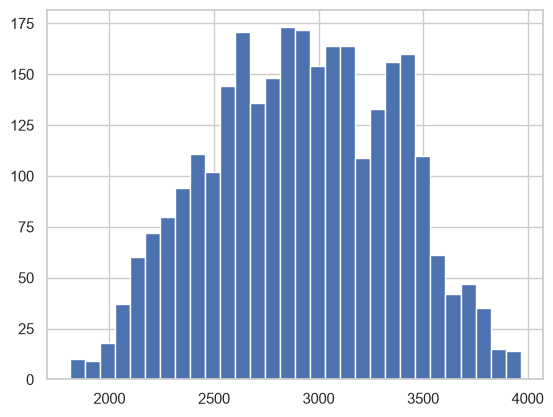

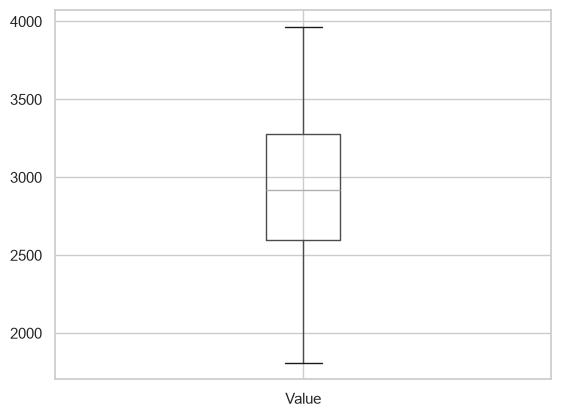

count    2901.000000
mean     2920.526667
std       442.464516
min      1810.450000
25%      2595.440000
50%      2918.240000
75%      3276.980000
max      3966.570000
Name: Value, dtype: float64

Skewness: -0.06007523604420201


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value


In [22]:
distr(fbs_country, "Value")

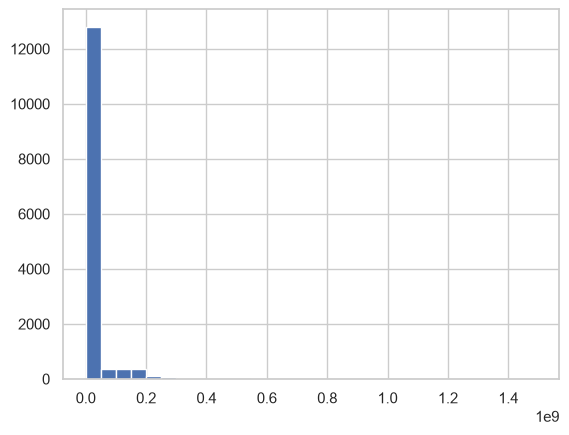

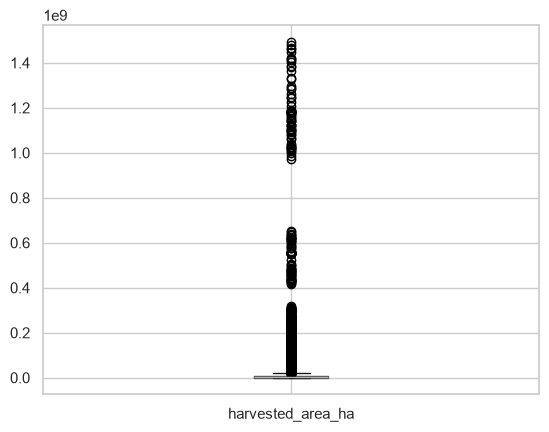

count    1.421500e+04
mean     2.489241e+07
std      9.695238e+07
min      0.000000e+00
25%      1.613925e+05
50%      1.530923e+06
75%      8.718265e+06
max      1.493960e+09
Name: harvested_area_ha, dtype: float64

Skewness: 9.135518754716385


,Area Code,Area,Year,harvested_area_ha
388,9,Argentina,1996,23273540.0
389,9,Argentina,1997,23085740.0
390,9,Argentina,1998,23629416.0
391,9,Argentina,1999,25306487.0
392,9,Argentina,2000,25559607.0
...,...,...,...,...
14210,5817,Net Food Importing Developing Countries (NFIDCs),2020,293780665.0
14211,5817,Net Food Importing Developing Countries (NFIDCs),2021,294342081.0
14212,5817,Net Food Importing Developing Countries (NFIDCs),2022,296321902.0
14213,5817,Net Food Importing Developing Countries (NFIDCs),2023,298790308.0


In [23]:
distr(qcl_area_total, "harvested_area_ha")

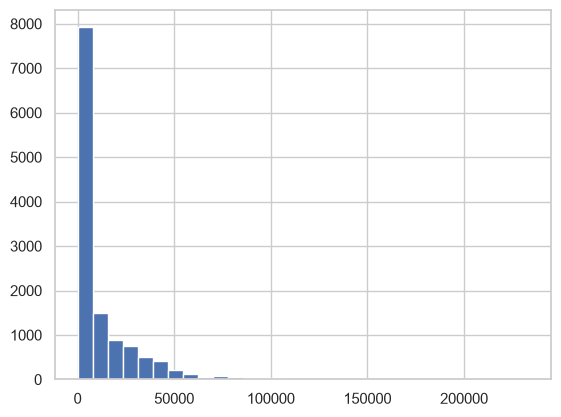

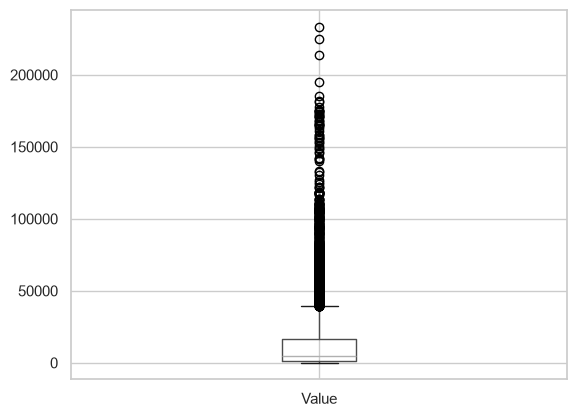

count     12697.000000
mean      12944.115846
std       20336.941300
min          92.932519
25%        1435.618270
50%        4432.212974
75%       16600.791393
max      233441.736636
Name: Value, dtype: float64

Skewness: 3.3933594335254336


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
165,MK,Macro Indicators,6,Andorra,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1970,1970,USD,44863.797234
166,MK,Macro Indicators,6,Andorra,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1971,1971,USD,43741.866626
167,MK,Macro Indicators,6,Andorra,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1972,1972,USD,44183.777744
168,MK,Macro Indicators,6,Andorra,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1973,1973,USD,44583.757723
169,MK,Macro Indicators,6,Andorra,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,1974,1974,USD,44193.697564
...,...,...,...,...,...,...,...,...,...,...,...,...
12197,MK,Macro Indicators,5501,Australia and New Zealand,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,2020,2020,USD,50989.342372
12198,MK,Macro Indicators,5501,Australia and New Zealand,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,2021,2021,USD,52751.474517
12199,MK,Macro Indicators,5501,Australia and New Zealand,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,2022,2022,USD,54045.842271
12200,MK,Macro Indicators,5501,Australia and New Zealand,6185,"Value US$ per capita, 2015 prices",22008,Gross Domestic Product,2023,2023,USD,54265.724271


In [24]:
distr(gdp_per_capita,"Value")

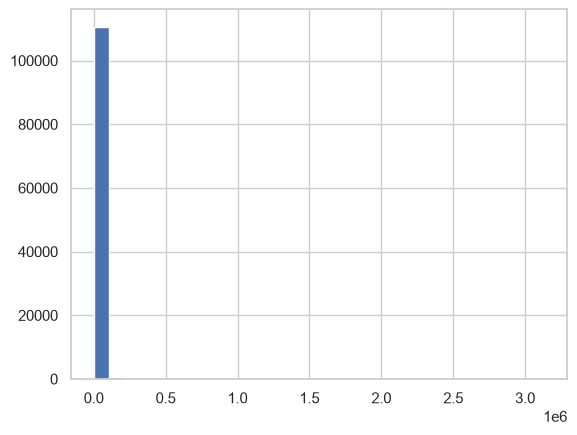

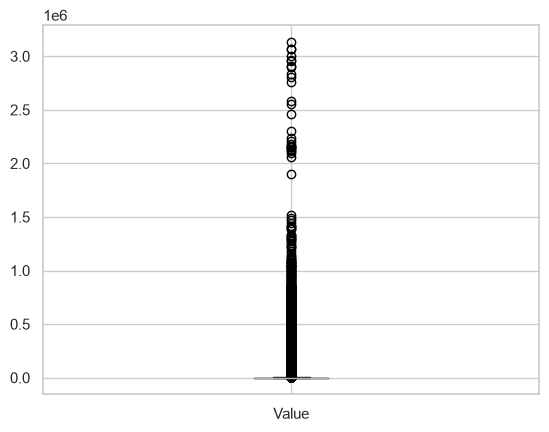

count    1.120080e+05
mean     7.412772e+03
std      6.227570e+04
min      0.000000e+00
25%      7.000000e+00
50%      9.100000e+01
75%      8.890000e+02
max      3.135773e+06
Name: Value, dtype: float64

Skewness: 24.2692721372645


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,FBS,Food Balances (2010-),2,Afghanistan,5511,Production,2905,Cereals - Excluding Beer,2010,2010,1000 t,5957
2,FBS,Food Balances (2010-),2,Afghanistan,5511,Production,2905,Cereals - Excluding Beer,2011,2011,1000 t,4681
3,FBS,Food Balances (2010-),2,Afghanistan,5611,Import quantity,2905,Cereals - Excluding Beer,2011,2011,1000 t,2448
4,FBS,Food Balances (2010-),2,Afghanistan,5511,Production,2905,Cereals - Excluding Beer,2012,2012,1000 t,6379
6,FBS,Food Balances (2010-),2,Afghanistan,5511,Production,2905,Cereals - Excluding Beer,2013,2013,1000 t,6520
...,...,...,...,...,...,...,...,...,...,...,...,...
112003,FBS,Food Balances (2010-),5817,Net Food Importing Developing Countries (NFIDCs),5611,Import quantity,2928,Miscellaneous,2019,2019,1000 t,2338
112004,FBS,Food Balances (2010-),5817,Net Food Importing Developing Countries (NFIDCs),5611,Import quantity,2928,Miscellaneous,2020,2020,1000 t,2266
112005,FBS,Food Balances (2010-),5817,Net Food Importing Developing Countries (NFIDCs),5611,Import quantity,2928,Miscellaneous,2021,2021,1000 t,2464
112006,FBS,Food Balances (2010-),5817,Net Food Importing Developing Countries (NFIDCs),5611,Import quantity,2928,Miscellaneous,2022,2022,1000 t,2543


In [25]:
distr(fbs_trade,"Value")

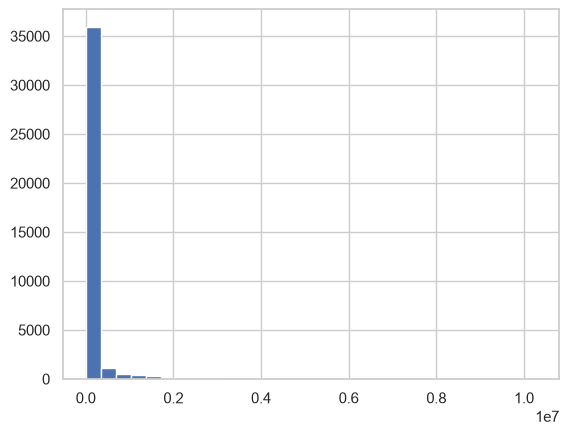

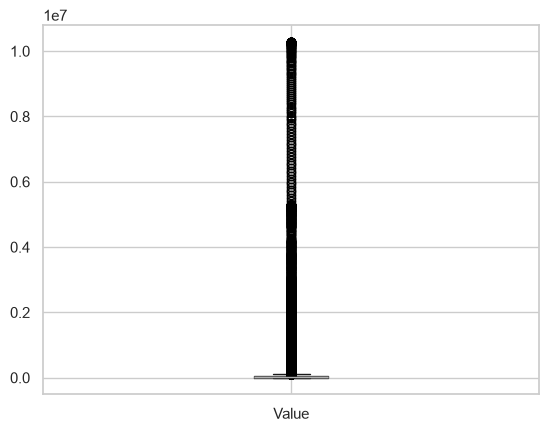

count    3.897300e+04
mean     1.427738e+05
std      6.425243e+05
min      1.552000e+00
25%      5.504040e+02
50%      7.016565e+03
75%      4.329455e+04
max      1.028931e+07
Name: Value, dtype: float64

Skewness: 9.781366186228986


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
124,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2074,2074,1000 No,108265.518
125,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2075,2075,1000 No,109352.869
126,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2076,2076,1000 No,110399.880
127,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2077,2077,1000 No,111475.822
128,OA,Annual population,2,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2078,2078,1000 No,112514.314
...,...,...,...,...,...,...,...,...,...,...,...,...
38968,OA,Annual population,5817,Net Food Importing Developing Countries (NFIDCs),511,Total Population - Both sexes,3010,Population - Est. & Proj.,2096,2096,1000 No,4144125.869
38969,OA,Annual population,5817,Net Food Importing Developing Countries (NFIDCs),511,Total Population - Both sexes,3010,Population - Est. & Proj.,2097,2097,1000 No,4158246.297
38970,OA,Annual population,5817,Net Food Importing Developing Countries (NFIDCs),511,Total Population - Both sexes,3010,Population - Est. & Proj.,2098,2098,1000 No,4171739.404
38971,OA,Annual population,5817,Net Food Importing Developing Countries (NFIDCs),511,Total Population - Both sexes,3010,Population - Est. & Proj.,2099,2099,1000 No,4184643.628


In [26]:
distr(population,"Value")

Harvested area and GDP per capita are strongly right-skewed:
- Harvested area: a few very large agricultural countries have much more harvested area than small countries.
- GDP per capita: a relatively small number of wealthy countries have values far above the majority.

Hewever, these should be real observations, not data-quality errors.

---
## 5. Categorical columns


In [27]:
fbs_products.nunique().sort_values()

Domain Code         1
Domain              1
Element             1
Element Code        1
Unit                1
Year Code          14
Year               14
Item              117
Item Code         120
Area              213
Area Code         213
Value           42318
dtype: int64

In [28]:
fbs_country.nunique().sort_values()

Domain Code        1
Domain             1
Element            1
Element Code       1
Item Code          1
Item               1
Unit               1
Year Code         14
Year              14
Area             213
Area Code        213
Value           2864
dtype: int64

In [29]:
fbs_country

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2010,2010,kcal/cap/d,2200.21
1,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2011,2011,kcal/cap/d,2171.86
2,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2012,2012,kcal/cap/d,2165.88
3,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2013,2013,kcal/cap/d,2205.33
4,FBS,Food Balances (2010-),2,Afghanistan,664,Food supply (kcal/capita/day),2901,Grand Total,2014,2014,kcal/cap/d,2270.45
...,...,...,...,...,...,...,...,...,...,...,...,...
2896,FBS,Food Balances (2010-),5817,Net Food Importing Developing Countries (NFIDCs),664,Food supply (kcal/capita/day),2901,Grand Total,2019,2019,kcal/cap/d,2521.46
2897,FBS,Food Balances (2010-),5817,Net Food Importing Developing Countries (NFIDCs),664,Food supply (kcal/capita/day),2901,Grand Total,2020,2020,kcal/cap/d,2545.37
2898,FBS,Food Balances (2010-),5817,Net Food Importing Developing Countries (NFIDCs),664,Food supply (kcal/capita/day),2901,Grand Total,2021,2021,kcal/cap/d,2554.74
2899,FBS,Food Balances (2010-),5817,Net Food Importing Developing Countries (NFIDCs),664,Food supply (kcal/capita/day),2901,Grand Total,2022,2022,kcal/cap/d,2543.78


In [30]:
qcl_area_total.nunique().sort_values()

Year                    64
Area Code              244
Area                   244
harvested_area_ha    13949
dtype: int64

In [31]:
gdp_per_capita.nunique().sort_values()

Domain Code         1
Domain              1
Element             1
Element Code        1
Item Code           1
Item                1
Unit                1
Year Code          55
Year               55
Area              244
Area Code         244
Value           12697
dtype: int64

In [32]:
shared_columns = set(fbs_country.columns)&set(fbs_products.columns)&set(qcl_area_total.columns)&set(gdp_per_capita.columns)
shared_columns

{'Area', 'Area Code', 'Year'}

---
## 6. Research questions

1-How does dietary energy supply (DES, kcal/person/day) differ across countries and regions, by year?

2-Which countries show the strongest increase or decline in DES over time?

3-Which food products/groups contribute most to DES, and how does this composition differ by year?

4-Which food products/groups show the strongest increase or decline in their contribution to DES over time?

5-Does harvested agricultural area per person relate to dietary energy supply, and which countries have relatively high harvested area per person but low DES?

6-Which food product groups are most associated with rising imports and declining domestic production as GDP per capita grows?


---
## 7. Into notebook 02

Tables

- `datasets` — FAOSTAT dataset metadata
- `areas` — unique area/country codes and names
- `fbs_country` — country-level DES observations
- `fbs_products` — product-level DES observations
- `harvested_area` — total harvested area by country and year
- `gdp_per_capita` — GDP per capita by country and year
- `population` — total population by country and year
- `fbs_trade` — production and import quantities by country, year and product

In [33]:
fbs_country.to_csv("../data/raw/fbs_country.csv", index=False)
fbs_products.to_csv("../data/raw/fbs_products.csv", index=False)
qcl_area.to_csv("../data/raw/qcl_area.csv", index=False)
gdp_per_capita.to_csv("../data/raw/gdp_per_capita.csv", index=False)
df_fao_list_datasets.to_csv("../data/raw/fao_list_datasets.csv", index=False)
population.to_csv("../data/raw/population.csv", index=False)
fbs_trade.to_csv("../data/raw/fbs_trade.csv", index=False)